In [2]:
# ==== Import Required Libraries ====
import numpy as np                # For numerical array and statistics
import matplotlib.pyplot as plt   # For plotting and saving the image
from scipy.special import sph_harm # For spherical harmonics 

## Loading the data

I saved the data $\delta T (\theta, \phi)$ from PLNACK as a table in `Planck_data.txt`. This is a truncated data-set, meaning that I reduced the resolution to speed up the calculation and reduce the file size. 

Let's load it and plot the data in the Mollweide projection. 

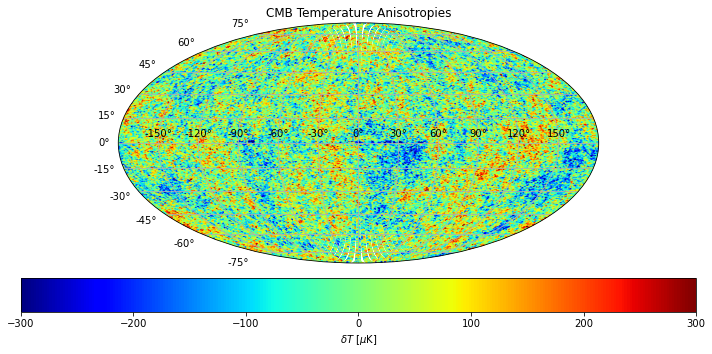

In [35]:
# ==== Plot CMB map using theta, phi, T ====

#load data
theta, phi, temperature = np.loadtxt("Planck_data.txt").T

# Convert coordinates
lon = phi - np.pi          # [-pi, pi]
#lon = -((phi + np.pi) % (2 * np.pi) - np.pi)
lat = np.pi/2 - theta      # [-pi/2, pi/2]

# Subsample for speed (adjust if needed)
step = 10
lon_s = lon[::step]
lat_s = lat[::step]
T_s   = temperature[::step]

# Create Mollweide projection and plot
plt.figure(figsize=(10, 5))
ax = plt.subplot(111, projection='mollweide')
sc = ax.scatter(
    lon_s, lat_s,
    c=T_s,
    s=2,
    cmap='jet',
    vmin=-300, vmax=300
)
ax.set_title("CMB Temperature Anisotropies")
ax.grid(True)
plt.colorbar(sc, orientation='horizontal', pad=0.05, label=r"$\delta T$ [$\mu$K]")
plt.tight_layout()
plt.show()

Let's expand the map in spherical harmonics 

$$\delta T (\theta, \phi)= \sum a_{l,m} Y_{l,m} (\theta,\phi).$$ 

Then we can calculate the coefficents 

$$a_{l,m} = \int d\Omega \delta T (\theta, \phi) Y^*_{l,m} (\theta,\phi) = \frac{4\pi}{N} \sum_{i=1}^{N} \delta T_i \cdot Y^*_{l,m}(\theta_i, \phi_i)$$ 

where we have used that the data is given by a uniformly distributed dataset $\{\theta_i, \phi_i, \delta T_i\}$. We then calculate 

$$C_l = \langle |a_{l,m}^2| \rangle  = \frac{1}{m_\text{max}} \sum_{m=0}^{m_\text{max}} a_{l,m}^2$$

where we choose $m_\text{max} = \text{min}(l,50)$ to speed up the calculation. This also avoids the high-m spherical harmonics, which suffer from numerical instabilities: I found that $Y_{lm}(\theta,\phi)$ for $m\gtrsim 80 $ returns `np.nan`. We can then define $D_l = C_l  \times l (l+1) / 2\pi$. 

In [4]:


def get_dl(temperature, theta, phi, l=50, m_max=50, m_min=0):
    
    npix = len(temperature)
    dOmega = 4 * np.pi / npix

    alms=[]
    mmax = min(l, m_max)
    for m in range(m_min, mmax + 1):
        if abs(m)>m_max: continue
        if abs(m)<m_min: continue
        Ylm = sph_harm(m, l, phi, theta)
        alm= np.dot(temperature , np.conj(Ylm)) * dOmega
        alms.append(abs(alm)**2)
    l_factor = l*(l+1)/(2.*np.pi)
    mean_cl, var_cl = np.mean(alms), np.std(alms) /np.sqrt(mmax-m_min)
    mean_dl, var_dl = mean_cl * l_factor , var_cl * l_factor
    print ("D(l =", l, ") = ", mean_dl, "+/-", var_dl)
    return mean_dl, var_dl 

Let's run $l=100$ as a test. The result should be $D_l \approx 2500$.

In [5]:
%%time
_=get_dl(temperature, theta, phi, l=100,  m_max=50)

D(l = 100 ) =  2292.7185703815308 +/- 335.6247406082319
Wall time: 2min 27s


The run-time for one value of $l$ is about 1 minute. So let's just consider a few values of $l = 50, 100, ... 500$ and compute $D_l$

In [6]:
l_values = [int(l) for l in np.linspace(50,500,10)]
d_values = [get_dl(temperature, theta, phi, l=l,  m_max=50) for l in l_values] 

D(l = 50 ) =  1553.4098005103924 +/- 204.50381267340296
D(l = 100 ) =  2292.7185703815308 +/- 335.6247406082319
D(l = 150 ) =  4518.3110539736 +/- 690.9151290264684
D(l = 200 ) =  5445.350483705386 +/- 789.679188828636
D(l = 250 ) =  4656.462576838952 +/- 560.134457024752
D(l = 300 ) =  3349.4424912118884 +/- 463.71313997913614
D(l = 350 ) =  1588.1751711623397 +/- 200.3368107554918
D(l = 400 ) =  994.3543712314737 +/- 110.08893559721466
D(l = 450 ) =  860.4115943230796 +/- 142.06671318100672
D(l = 500 ) =  1125.4017413182899 +/- 154.8063829965322


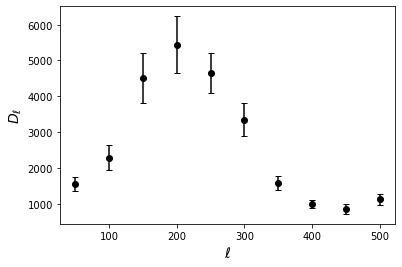

In [7]:
dl_mean = [d[0] for d in d_values]
dl_std  = [d[1] for d in d_values]

fig, ax = plt.subplots()
ax.errorbar(l_values, dl_mean, yerr=dl_std, fmt='o', capsize=3, c='k')
ax.set_xlabel(r'$\ell$', fontsize=14)
ax.set_ylabel(r'$D_\ell$', fontsize=14)
plt.show()

## Extracting the peak
You can just select the largest value of $D_{\ell}$ and get a pretty good estimate of the peak. I also did a polynomial interpolation to check the maximum. You should find $\ell\sim 200$ which corresponds to: $$\theta\simeq \frac{\pi}{\ell}\sim 0.9^{\circ}$$
A more accurate analysis of the power spectrum without rejecting the high-$m$ modes gives $\ell\sim 220$ corresponding to $\theta\sim 0.7^{\circ}$

In [8]:
l_arr = np.array(l_values)
dl_arr = np.array(dl_mean)
dl_err = np.array(dl_std)

# Find the largest computed point
imax = np.argmax(dl_arr)

l_peak_discrete = l_arr[imax]
dl_peak_discrete = dl_arr[imax]

print("Discrete peak estimate:")
print(f"l_peak ≈ {l_peak_discrete}")
print(f"D_l_peak ≈ {dl_peak_discrete:.3e}")

Discrete peak estimate:
l_peak ≈ 200
D_l_peak ≈ 5.445e+03


In [30]:
# Polynomial fit to estimate the first peak 

l_arr = np.array(l_values)
dl_arr = np.array(dl_mean)
dl_err = np.array(dl_std)

#fit only the peak
fit_mask = (l_arr >= 100) & (l_arr <= 350)

x_fit = l_arr[fit_mask]
y_fit = dl_arr[fit_mask]
sigma_fit = dl_err[fit_mask]

# Avoid zero uncertainties
sigma_fit = np.where(sigma_fit <= 0, np.std(y_fit), sigma_fit)


x0 = np.mean(x_fit)
xscale = np.std(x_fit)

x_scaled = (x_fit - x0) / xscale

# polynomial degree
degree = 4


coeffs = np.polyfit(
    x_scaled,
    y_fit,
    deg=degree,
    w=1/sigma_fit
)


def poly_Dl(l):
    l_scaled = (l - x0) / xscale
    return np.polyval(coeffs, l_scaled)


l_smooth = np.linspace(x_fit.min(), x_fit.max(), 1000)
dl_smooth = poly_Dl(l_smooth)

# maximum of fitted curve
imax = np.argmax(dl_smooth)

l_peak_poly = l_smooth[imax]
Dl_peak_poly = dl_smooth[imax]

print(f"Polynomial degree = {degree}")
print(f"Estimated first peak:")
print(f"ell_peak ≈ {ell_peak_poly:.2f}")
print(f"D_l_peak ≈ {Dl_peak_poly:.3e}")

Polynomial degree = 4
Estimated first peak:
ell_peak ≈ 200.60
D_l_peak ≈ 5.291e+03


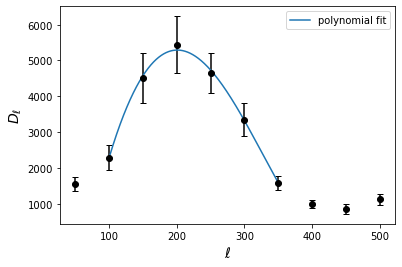

In [33]:
fig, ax = plt.subplots()

ax.errorbar(
    l_values, dl_mean, yerr=dl_std,
    fmt='o', capsize=3, c='k',
    #label=r"$D_\ell$"
)

ax.plot(
    ell_smooth, dl_smooth,
    label="polynomial fit"
)


ax.set_xlabel(r'$\ell$', fontsize=14)
ax.set_ylabel(r'$D_\ell$', fontsize=14)
ax.legend()
plt.show()

In [34]:
#angular scale
theta_peak_rad = np.pi / l_peak_poly
theta_peak_deg = theta_peak_rad * 180 / np.pi

print(f"theta_peak ≈ {theta_peak_rad:.4f} rad")
print(f"theta_peak ≈ {theta_peak_deg:.3f} degrees")

theta_peak ≈ 0.0157 rad
theta_peak ≈ 0.897 degrees
